In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# **CONFIG**

In [2]:
SUBMISSION_PATH = Path("../data/submission/submission_03_convnext_20260715_1216.csv")

GROUND_TRUTH_PATH = Path("../data/kuncijawaban.csv")
TEST_DATA_DIR = Path("../data/test")

RAW_FOLDER_TO_CLASS_NAME = {
    "0_Recyclable": "Recyclable",
    "1_Electronic": "Electronic",
    "2_Organic": "Organic",
}
COMPETITION_LABEL_TO_NAME = {
    int(raw_folder.split("_")[0]): class_name
    for raw_folder, class_name in RAW_FOLDER_TO_CLASS_NAME.items()
}
CLASS_NAMES = [COMPETITION_LABEL_TO_NAME[k] for k in sorted(COMPETITION_LABEL_TO_NAME)]

print(f"Submission : {SUBMISSION_PATH}")
print(f"Label map  : {COMPETITION_LABEL_TO_NAME}")

Submission : ../data/submission/submission_03_convnext_20260715_1216.csv
Label map  : {0: 'Recyclable', 1: 'Electronic', 2: 'Organic'}


# **LOAD & MERGE**

In [3]:
ground_truth_df = pd.read_csv(GROUND_TRUTH_PATH)
submission_df = pd.read_csv(SUBMISSION_PATH)

print(f"Ground truth rows : {len(ground_truth_df)}")
print(f"Submission rows   : {len(submission_df)}")

missing_in_submission = set(ground_truth_df["id"]) - set(submission_df["id"])
extra_in_submission = set(submission_df["id"]) - set(ground_truth_df["id"])
if missing_in_submission:
    print(
        f"WARNING: {len(missing_in_submission)} id ground truth tidak ada di submission"
    )
if extra_in_submission:
    print(
        f"WARNING: {len(extra_in_submission)} id submission tidak ada di ground truth"
    )

ground_truth_df = ground_truth_df.rename(columns={"predicted": "true_label"})
submission_df = submission_df.rename(columns={"predicted": "pred_label"})

eval_df = ground_truth_df.merge(
    submission_df, on="id", how="inner", validate="one_to_one"
)
eval_df["is_correct"] = eval_df["true_label"] == eval_df["pred_label"]

print(f"Evaluated rows    : {len(eval_df)}")
eval_df.head()

Ground truth rows : 1458
Submission rows   : 1458
Evaluated rows    : 1458


,id,true_label,pred_label,is_correct
0,1,2,2,True
1,2,2,2,True
2,3,2,2,True
3,4,1,1,True
4,5,0,0,True


# **OVERALL METRICS**

In [4]:
overall_accuracy = accuracy_score(eval_df["true_label"], eval_df["pred_label"])
print("=" * 50)
print("EVALUASI SUBMISSION")
print("=" * 50)
print(f"Submission     : {SUBMISSION_PATH.name}")
print(f"Total sample   : {len(eval_df)}")
print(f"Accuracy       : {overall_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        eval_df["true_label"],
        eval_df["pred_label"],
        labels=sorted(COMPETITION_LABEL_TO_NAME),
        target_names=CLASS_NAMES,
    )
)

EVALUASI SUBMISSION
Submission     : submission_03_convnext_20260715_1216.csv
Total sample   : 1458
Accuracy       : 93.14%

Classification Report:
              precision    recall  f1-score   support

  Recyclable       0.98      0.84      0.91       558
  Electronic       0.96      0.97      0.96       199
     Organic       0.90      0.99      0.94       701

    accuracy                           0.93      1458
   macro avg       0.94      0.93      0.94      1458
weighted avg       0.94      0.93      0.93      1458



# **CONFUSION MATRIX**

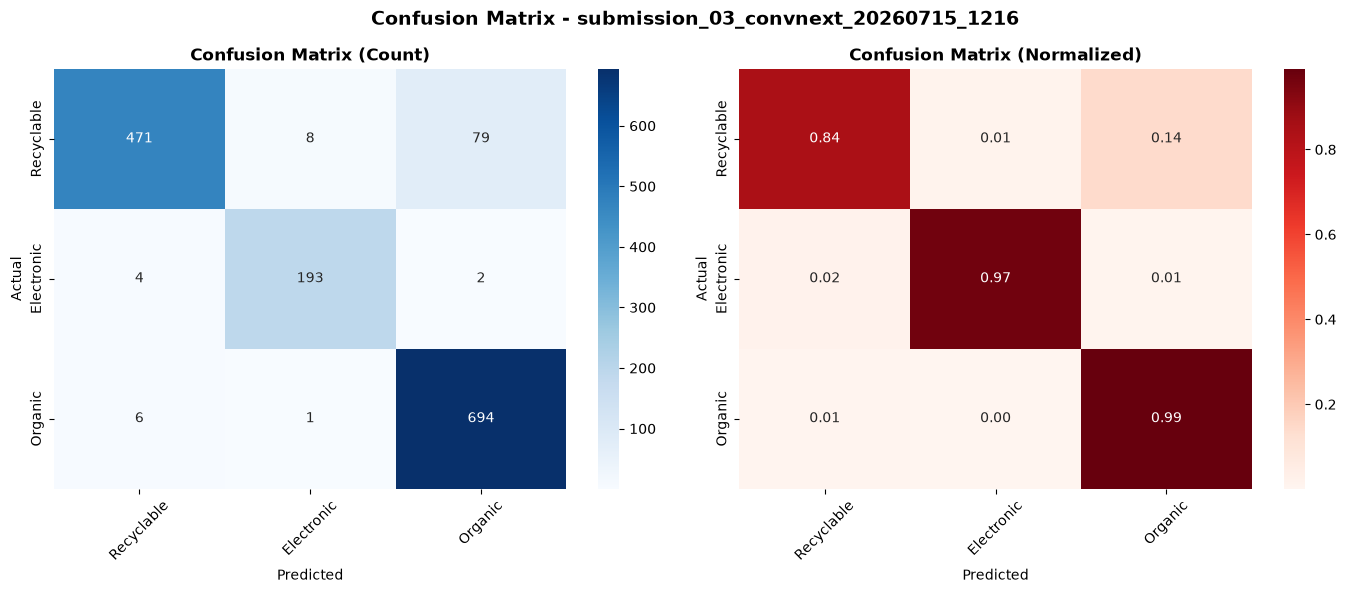

In [5]:
conf_matrix = confusion_matrix(
    eval_df["true_label"],
    eval_df["pred_label"],
    labels=sorted(COMPETITION_LABEL_TO_NAME),
)
conf_matrix_normalized = (
    conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis]
)

fig, (ax_count, ax_norm) = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax_count,
)
ax_count.set_title("Confusion Matrix (Count)", fontweight="bold")
ax_count.set_xlabel("Predicted")
ax_count.set_ylabel("Actual")
ax_count.tick_params(axis="x", rotation=45)

sns.heatmap(
    conf_matrix_normalized,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax_norm,
)
ax_norm.set_title("Confusion Matrix (Normalized)", fontweight="bold")
ax_norm.set_xlabel("Predicted")
ax_norm.set_ylabel("Actual")
ax_norm.tick_params(axis="x", rotation=45)

plt.suptitle(
    f"Confusion Matrix - {SUBMISSION_PATH.stem}", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# **MISCLASSIFIED SAMPLES**

In [6]:
misclassified_df = eval_df[~eval_df["is_correct"]].copy()
misclassified_df["true_label_name"] = misclassified_df["true_label"].map(
    COMPETITION_LABEL_TO_NAME
)
misclassified_df["pred_label_name"] = misclassified_df["pred_label"].map(
    COMPETITION_LABEL_TO_NAME
)

print(f"Total misclassified: {len(misclassified_df)} / {len(eval_df)}")
misclassified_df[
    [
        "id",
        "true_label_name",
        "pred_label_name",
    ]
].head(20)

Total misclassified: 100 / 1458


,id,true_label_name,pred_label_name
5,6,Recyclable,Organic
16,17,Organic,Electronic
18,19,Recyclable,Organic
28,29,Recyclable,Organic
29,30,Recyclable,Organic
35,36,Recyclable,Organic
43,44,Recyclable,Organic
60,61,Electronic,Recyclable
65,66,Recyclable,Electronic
106,107,Recyclable,Organic


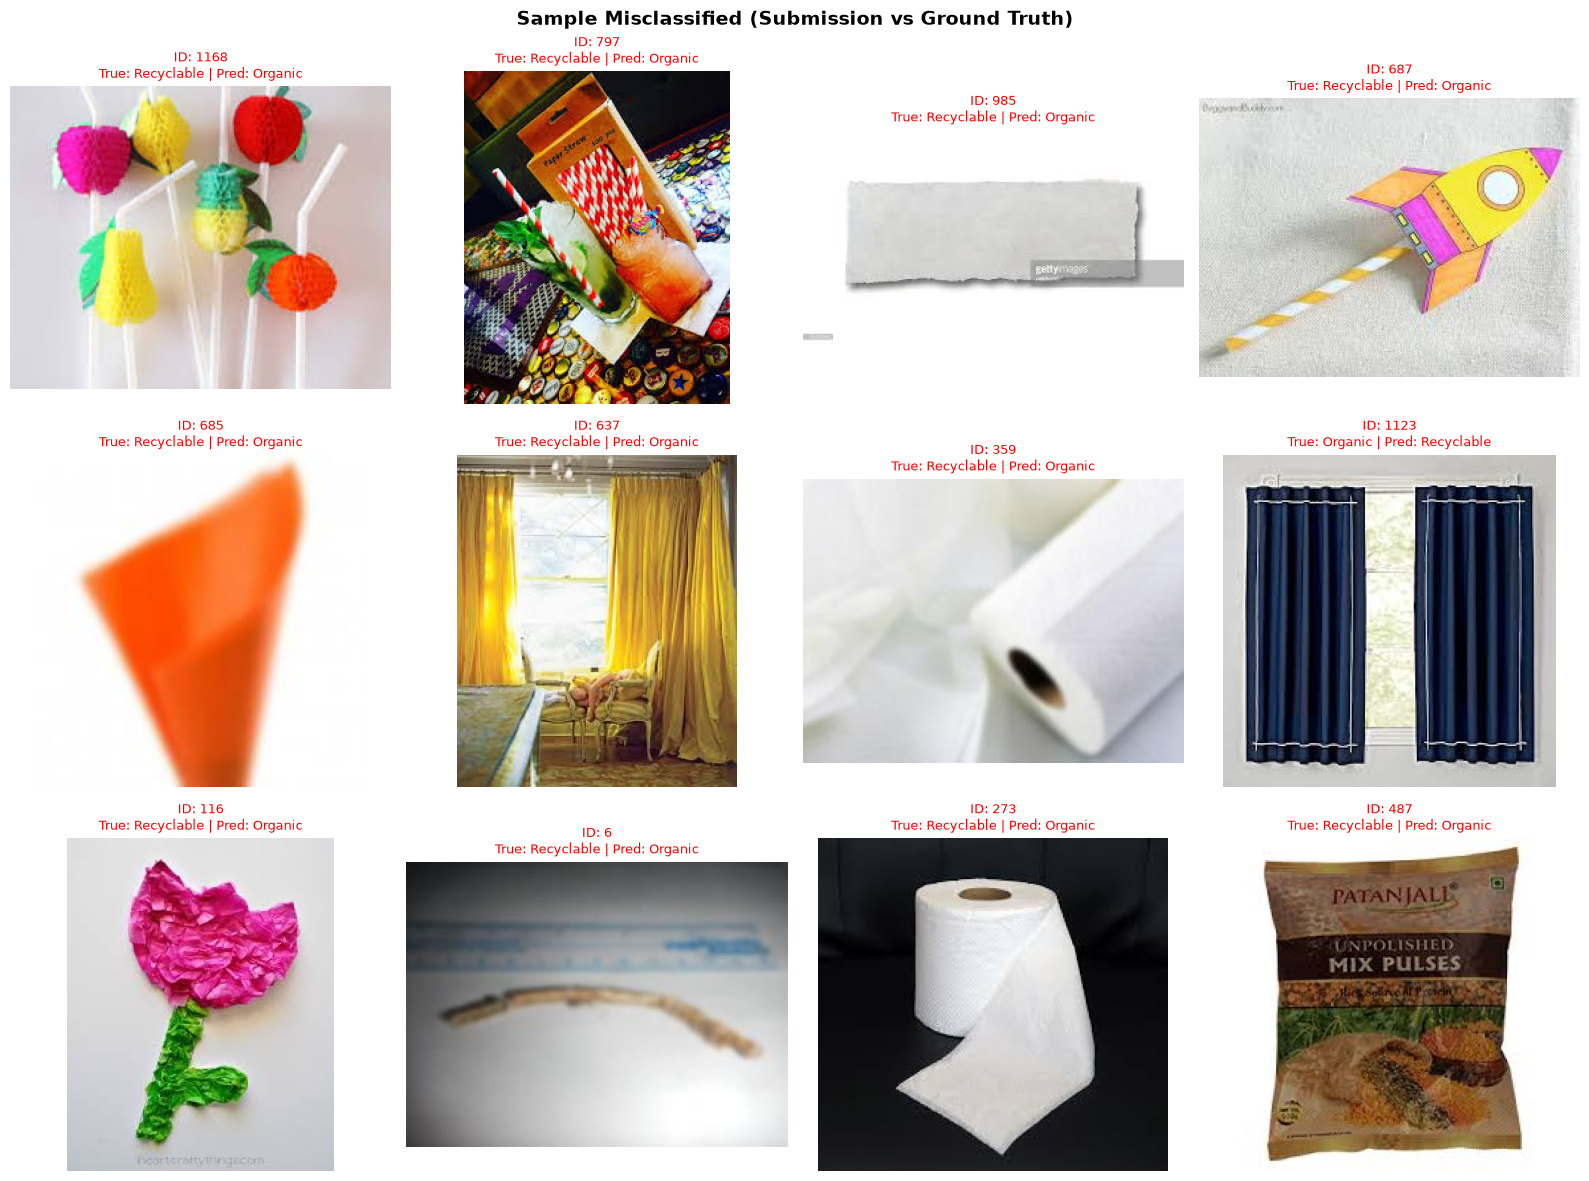

In [7]:
NUM_VIZ = 12
viz_rows = misclassified_df.sample(min(NUM_VIZ, len(misclassified_df)), random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for ax, (_, row) in zip(axes, viz_rows.iterrows()):
    img_path = TEST_DATA_DIR / f"{row['id']}.jpg"
    if not img_path.exists():
        img_path = TEST_DATA_DIR / f"{row['id']}.png"
    ax.imshow(Image.open(img_path).convert("RGB"))
    ax.set_title(
        f"ID: {row['id']}\nTrue: {row['true_label_name']} | Pred: {row['pred_label_name']}",
        fontsize=9,
        color="red",
    )
    ax.axis("off")

for ax in axes[len(viz_rows) :]:
    ax.axis("off")

plt.suptitle(
    "Sample Misclassified (Submission vs Ground Truth)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()